In [159]:
import ssl
import urllib.request

ssl._create_default_https_context = ssl._create_unverified_context

In [1]:
# 📦 Standard Libraries
import re
import string
import math
import numpy as np
import pandas as pd
from argparse import Namespace

# 📚 Text Processing
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# 🧠 Machine Learning & NLP
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import normalize
from sklearn.metrics import (
    silhouette_score,
    silhouette_samples,
    davies_bouldin_score,
)
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# 🧬 Vectorization
from gensim.models import FastText

# 📊 Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import plotly.express as px
import plotly.graph_objects as go

# 🌌 Dimensionality Reduction
import umap.umap_ as umap


In [2]:
# === Download necessary NLTK data ===
# nltk.download("punkt")
# nltk.download("stopwords")
# nltk.download("wordnet")

FINE_TUNED_DIR = '../../pretained_or_finetune-models'
REVIEWS_DATASET_DIR = '../../dataset'
UTILS_DIR = '../../utils'
NLTK_DATA_PATH = f"{FINE_TUNED_DIR}/nltk_data"

nltk.data.path.append(NLTK_DATA_PATH)

# === Constants ===
STOPWORDS = set(stopwords.words("english"))
LEMMATIZER = WordNetLemmatizer()
CONST_VECTOR_SIZE = 50
CONST_DIM_WINDOWS = 3

In [3]:
def advanced_clean_text(text):
    if not isinstance(text, str):
        return "other"  # Handle non-string values safely
    
    # Define domain-specific stopwords
    # custom_stopwords = {'point', 'points', 'interest', 'landmark', 'landmarks', 'site', 'sites'}  # Remove generic tourism terms
    
    text = text.lower()
    text = re.sub(r'\d+', '', text)  # Remove numbers
    text = re.sub(r'[^a-z\s]', '', text)  # Remove special characters
    text = re.sub(r'\b(u|ur|b4)\b', 'you', text)  # Replace common abbreviations

    words = text.split()  # ✅ Fix: Use split() instead of word_tokenize()
    words = [LEMMATIZER.lemmatize(word) for word in words if word not in STOPWORDS]
    words = [word for word in words if  word not in string.punctuation]  # Remove tourism-related stopwords

    return ' '.join(words)  

In [9]:
combined_details_df = pd.read_parquet("../../frontend/inputs/combined_details.parquet")

In [10]:
combined_details_df.head(5)

,location_id,name,description,web_url,latitude,longitude,website,write_review,rating,rating_image_url,...,rating_2_review_count,rating_3_review_count,rating_4_review_count,rating_5_review_count,tags,trip_types_solo,trip_types_couples,trip_types_business,trip_types_family,trip_types_friends
0,456633,House of Opium,Located in the heart of the infamous Golden Tr...,https://www.tripadvisor.com/Attraction_Review-...,20.351446,100.081660,https://www.tourismthailand.org/Attraction/Hou...,https://www.tripadvisor.com/UserReview-g317131...,4.0,https://www.tripadvisor.com/img/cdsi/img2/rati...,...,34,210,363,413,"History Museums, Specialty Museums",105,440,9,148,184
1,23933132,Opium Bar,None,https://www.tripadvisor.com/Attraction_Review-...,13.739190,100.508500,http://www.opiumbarbangkok.com/,https://www.tripadvisor.com/UserReview-g293916...,4.0,https://www.tripadvisor.com/img/cdsi/img2/rati...,...,0,1,0,4,Bars & Clubs,0,3,0,0,2
2,7099963,Wat Phra That Doi Saket,None,https://www.tripadvisor.com/Attraction_Review-...,18.872380,99.139930,None,https://www.tripadvisor.com/UserReview-g196165...,4.5,https://www.tripadvisor.com/img/cdsi/img2/rati...,...,0,5,31,44,Sacred & Religious Sites,9,26,0,14,21
3,1390125,Mae Ping River Cruise,Leave from the jetty at Wat Chai Mongkol and t...,https://www.tripadvisor.com/Attraction_Review-...,18.780819,99.005210,http://www.maepingrivercruise.com/,https://www.tripadvisor.com/UserReview-g293917...,3.5,https://www.tripadvisor.com/img/cdsi/img2/rati...,...,43,98,127,102,Boat Tours,31,186,2,43,57
4,547675,Pai River,None,https://www.tripadvisor.com/Attraction_Review-...,19.359318,98.445305,None,https://www.tripadvisor.com/UserReview-g303916...,4.0,https://www.tripadvisor.com/img/cdsi/img2/rati...,...,6,46,58,52,Bodies of Water,30,56,1,15,46


In [12]:
combined_details_df['tags'] = combined_details_df['tags'].fillna("").astype(str)
combined_details_df['tags'].replace("", "other", inplace=True)

/var/folders/fk/449tdf_12hzd2r7ps4659q0m0000gn/T/ipykernel_2145/4017882174.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  combined_details_df['tags'].replace("", "other", inplace=True)


In [13]:
combined_details_df['label'] = combined_details_df['tags'].apply(lambda x: x.split(',')[0])

In [14]:

combined_details_df['tags'] = combined_details_df['tags'].apply(advanced_clean_text)
combined_details_df['tags']

0                    history museum specialty museum
1                                           bar club
2                              sacred religious site
3                                          boat tour
4                                         body water
                            ...                     
1761                                           beach
1762                                          bridge
1763    sacred religious site architectural building
1764                                           beach
1765                                         lookout
Name: tags, Length: 1766, dtype: object

In [15]:
combined_details_df['label'] = combined_details_df['label'].apply(advanced_clean_text)
combined_details_df['label'] = combined_details_df['label'].fillna("").astype(str)
combined_details_df['label'].replace("", "other", inplace=True)
combined_details_df['label']

/var/folders/fk/449tdf_12hzd2r7ps4659q0m0000gn/T/ipykernel_2145/348596639.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  combined_details_df['label'].replace("", "other", inplace=True)


0              history museum
1                    bar club
2       sacred religious site
3                   boat tour
4                  body water
                ...          
1761                    beach
1762                   bridge
1763    sacred religious site
1764                    beach
1765                  lookout
Name: label, Length: 1766, dtype: object

In [16]:
# แปลงข้อมูลเป็น String
tags = combined_details_df['tags'].astype(str)

# ใช้ TF-IDF Vectorizer
vectorizer = TfidfVectorizer(tokenizer=lambda x: x.lower().split(" "), stop_words='english')

# Fit Transform
X = vectorizer.fit_transform(tags)

# ดึง Feature Names (คำที่สำคัญ)
feature_names = np.array(vectorizer.get_feature_names_out())

# คำนวณ TF-IDF และเลือกคำที่มีค่ามากที่สุดในแต่ละแถว
important_words = []
for row in X:
    row_data = row.toarray().flatten()
    best_word_index = np.argmax(row_data)  # Index ของคำที่สำคัญที่สุด
    best_word = feature_names[best_word_index] if row_data[best_word_index] > 0 else None
    important_words.append(best_word)

# เพิ่มคอลัมน์ใหม่
combined_details_df["keyword"] = important_words

# ดูผลลัพธ์
(combined_details_df[["name", "tags", "keyword"]].head(10))

/Users/ittichaiboonyarakthunya/Documents/WorkDir/developments/IS_Project/.venv/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


,name,tags,keyword
0,House of Opium,history museum specialty museum,museum
1,Opium Bar,bar club,bar
2,Wat Phra That Doi Saket,sacred religious site,religious
3,Mae Ping River Cruise,boat tour,boat
4,Pai River,body water,body
5,Doi Chang Mub Arboretum,point interest landmark lookout,lookout
6,Tung Dok Bua Tong Doi Hua Mae Kum,garden,garden
7,Golden Triangle,point interest landmark,landmark
8,Golden Triangle Tours - Day Tours,sightseeing tour,sightseeing
9,Bo Nam Ron Krung Ching,hot spring geyser,geyser


In [6]:
# combined_details_df.to_parquet("./input/combined_details_df.parquet", compression="gzip", engine="pyarrow", index=False)
# combined_details_df.to_csv("./input/combined_details_df.csv", index=False, encoding="utf-8")
combined_details_df = pd.read_parquet("./input/combined_details_df.parquet")
combined_details_df

,location_id,name,description,web_url,latitude,longitude,website,write_review,rating,rating_image_url,...,rating_4_review_count,rating_5_review_count,tags,trip_types_solo,trip_types_couples,trip_types_business,trip_types_family,trip_types_friends,label,keyword
0,456633,House of Opium,Located in the heart of the infamous Golden Tr...,https://www.tripadvisor.com/Attraction_Review-...,20.351446,100.081660,https://www.tourismthailand.org/Attraction/Hou...,https://www.tripadvisor.com/UserReview-g317131...,4.0,https://www.tripadvisor.com/img/cdsi/img2/rati...,...,363,413,history museum specialty museum,105,440,9,148,184,history museum,museum
1,23933132,Opium Bar,None,https://www.tripadvisor.com/Attraction_Review-...,13.739190,100.508500,http://www.opiumbarbangkok.com/,https://www.tripadvisor.com/UserReview-g293916...,4.0,https://www.tripadvisor.com/img/cdsi/img2/rati...,...,0,4,bar club,0,3,0,0,2,bar club,bar
2,7099963,Wat Phra That Doi Saket,None,https://www.tripadvisor.com/Attraction_Review-...,18.872380,99.139930,None,https://www.tripadvisor.com/UserReview-g196165...,4.5,https://www.tripadvisor.com/img/cdsi/img2/rati...,...,31,44,sacred religious site,9,26,0,14,21,sacred religious site,religious
3,1390125,Mae Ping River Cruise,Leave from the jetty at Wat Chai Mongkol and t...,https://www.tripadvisor.com/Attraction_Review-...,18.780819,99.005210,http://www.maepingrivercruise.com/,https://www.tripadvisor.com/UserReview-g293917...,3.5,https://www.tripadvisor.com/img/cdsi/img2/rati...,...,127,102,boat tour,31,186,2,43,57,boat tour,boat
4,547675,Pai River,None,https://www.tripadvisor.com/Attraction_Review-...,19.359318,98.445305,None,https://www.tripadvisor.com/UserReview-g303916...,4.0,https://www.tripadvisor.com/img/cdsi/img2/rati...,...,58,52,body water,30,56,1,15,46,body water,body
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1761,10053134,Chao Lao Beach,None,https://www.tripadvisor.com/Attraction_Review-...,12.533703,101.940470,None,https://www.tripadvisor.com/UserReview-g223726...,4.0,https://www.tripadvisor.com/img/cdsi/img2/rati...,...,25,19,beach,3,18,1,13,11,beach,beach
1762,23744675,Chao Lao Fish Bridge,None,https://www.tripadvisor.com/Attraction_Review-...,12.571852,101.923390,None,https://www.tripadvisor.com/UserReview-g323879...,4.0,https://www.tripadvisor.com/img/cdsi/img2/rati...,...,1,0,bridge,0,0,0,0,0,bridge,bridge
1763,10266462,Wat Burapa Temple,None,https://www.tripadvisor.com/Attraction_Review-...,15.230770,104.865680,None,https://www.tripadvisor.com/UserReview-g656472...,3.5,https://www.tripadvisor.com/img/cdsi/img2/rati...,...,1,0,sacred religious site architectural building,1,0,1,0,2,sacred religious site,architectural
1764,12881708,Kung Wiman Beach,None,https://www.tripadvisor.com/Attraction_Review-...,12.608021,101.870415,None,https://www.tripadvisor.com/UserReview-g223726...,4.0,https://www.tripadvisor.com/img/cdsi/img2/rati...,...,7,5,beach,1,4,0,4,3,beach,beach


In [7]:
from collections import Counter


all_tags = [tag.strip() for tags in combined_details_df['tags'].dropna() for tag in tags.lower().split(", ")]
tag_counts = Counter(all_tags)

def select_most_frequent(tag_string):
    tags = tag_string.lower().split(", ")  # แก้ให้แยกคำตาม ", "
    return max(tags, key=lambda tag: tag_counts[tag]) if tags else None

combined_details_df["frequncy_keyword"] = combined_details_df["tags"].astype(str).apply(select_most_frequent)

print(combined_details_df[["tags", "frequncy_keyword", "label"]].head())

                              tags                 frequncy_keyword  \
0  history museum specialty museum  history museum specialty museum   
1                         bar club                         bar club   
2            sacred religious site            sacred religious site   
3                        boat tour                        boat tour   
4                       body water                       body water   

                   label  
0         history museum  
1               bar club  
2  sacred religious site  
3              boat tour  
4             body water  


In [8]:
tag_counts

Counter({'point interest landmark': 215,
         'sacred religious site': 179,
         'flea street market': 80,
         'spa': 76,
         'beach': 75,
         'specialty museum': 69,
         'gift specialty shop': 64,
         'nature wildlife area': 48,
         'waterfall': 45,
         'shopping mall': 28,
         'island': 25,
         'bar club': 24,
         'park': 24,
         'body water': 23,
         'monument statue': 20,
         'farm': 19,
         'cavern cave': 19,
         'lookout': 18,
         'national park': 17,
         'cooking class': 17,
         'point interest landmark sacred religious site': 16,
         'nature wildlife tour': 16,
         'history museum': 15,
         'sacred religious site point interest landmark': 15,
         'scuba snorkeling': 14,
         'farmer market': 13,
         'mountain': 13,
         'garden': 12,
         'boat tour': 11,
         'zoo': 11,
         'historic site': 10,
         'golf course': 10,
         'tax

In [9]:
combined_details_df['label'].apply(type).value_counts()

label
<class 'str'>    1766
Name: count, dtype: int64

In [10]:
args = Namespace(
    VECTOR_SIZE=300,
    VECTOR_WINDOW_SIZE=10,
    VECTOR_MIN_COUNT=1,
    VECTOR_METHOD=0
)

In [11]:
sentences = [tags.split(", ") for tags in combined_details_df['label'].dropna()]

In [12]:
fasttext_model = FastText(sentences, vector_size=args.VECTOR_SIZE, window=args.VECTOR_WINDOW_SIZE, min_count=args.VECTOR_MIN_COUNT, sg=args.VECTOR_METHOD, epochs=20)

words = list(fasttext_model.wv.index_to_key)
vectors = [fasttext_model.wv[word] for word in words]

word_vectors = np.array([fasttext_model.wv[word] for word in words])

In [13]:
oov_vector = fasttext_model.wv["unseenword"]
oov_vector

array([ 1.20445591e-04,  5.83025743e-04, -2.53915845e-04,  5.96043421e-04,
       -1.18364675e-04, -6.50173053e-04, -7.43078999e-06, -2.01032031e-04,
        5.53272490e-04,  1.40356919e-04, -1.89257858e-04, -2.99028052e-05,
        4.88321675e-05, -3.43651118e-05,  1.83685755e-04, -2.79499538e-04,
        1.24197089e-04,  1.12606438e-04,  4.64877812e-05,  2.15204956e-04,
       -1.01932899e-04, -6.04774745e-04,  2.26455959e-04, -3.48730391e-04,
       -4.32477769e-04,  7.59188435e-04,  1.58976851e-04,  1.97457237e-04,
       -2.64717295e-04, -9.73245624e-05,  3.33968230e-04,  9.86684536e-05,
        5.04427706e-04,  3.53244570e-04, -2.65196606e-04, -1.61860487e-04,
        6.34458920e-05, -4.22653568e-04,  3.10557953e-04, -2.30940554e-04,
       -2.54022627e-04, -2.63774273e-04,  6.80564670e-04, -7.25177815e-04,
        2.82337365e-04, -2.89868040e-04, -5.76427439e-04,  4.15628136e-04,
        2.31080936e-04, -4.41960467e-04, -8.45062968e-05,  1.65154925e-04,
        5.13814506e-04,  

In [14]:
word_vectors[0]

array([-9.86550076e-05, -1.13737500e-04,  1.63038610e-04, -2.56310217e-04,
       -2.01345480e-04, -1.05989988e-04, -1.05155719e-04,  1.36605930e-04,
        7.14802154e-05,  1.91638464e-05,  3.69953748e-04, -6.58924619e-05,
        2.29195066e-04,  2.89855634e-05, -3.33485194e-04,  1.17887967e-05,
       -1.57817354e-04,  1.73304739e-04, -1.82299351e-04,  1.57375791e-04,
        2.31551545e-04,  1.61073782e-04, -2.48789700e-04, -2.91447126e-04,
       -2.96684739e-04, -1.39585871e-04, -2.96199978e-05,  1.01239129e-05,
       -7.92127976e-05, -3.53631156e-04,  1.34099857e-04, -2.37004278e-05,
        9.30474635e-05,  1.91458585e-05, -2.04065189e-04,  4.67593200e-05,
        4.10608976e-04, -3.00037034e-04,  2.72050165e-05,  1.25098872e-04,
       -1.10087829e-04,  1.49071508e-04, -2.11571445e-04, -3.33997537e-04,
       -3.13397413e-06, -8.46824114e-05,  3.57325742e-04,  2.90610060e-05,
        2.65841605e-04, -8.80107400e-05, -1.30840679e-04, -7.77549794e-05,
       -3.77727702e-04,  

In [15]:
sentences

[['history museum'],
 ['bar club'],
 ['sacred religious site'],
 ['boat tour'],
 ['body water'],
 ['point interest landmark'],
 ['garden'],
 ['point interest landmark'],
 ['sightseeing tour'],
 ['hot spring geyser'],
 ['national park'],
 ['flea street market'],
 ['shopping mall'],
 ['specialty museum'],
 ['historic site'],
 ['historic site'],
 ['zoo'],
 ['point interest landmark'],
 ['performance'],
 ['sacred religious site'],
 ['sacred religious site'],
 ['sacred religious site'],
 ['monument statue'],
 ['geologic formation'],
 ['specialty museum'],
 ['architectural building'],
 ['point interest landmark'],
 ['ancient ruin'],
 ['point interest landmark'],
 ['point interest landmark'],
 ['sacred religious site'],
 ['sacred religious site'],
 ['nature wildlife area'],
 ['spa'],
 ['zoo'],
 ['point interest landmark'],
 ['waterfall'],
 ['farmer market'],
 ['natural history museum'],
 ['point interest landmark'],
 ['specialty museum'],
 ['shopping mall'],
 ['mass transportation system'],
 

In [63]:
import sklearn

print(sklearn.__version__) 

1.6.1


In [18]:
word_vectors = normalize(word_vectors)
cosine_sim_matrix = cosine_similarity(word_vectors)

for threshold in [0.3, 0.4, 0.5, 0.6, 0.7, 0.8]:
    dbscan = DBSCAN(eps=threshold, min_samples=2, metric="cosine")  
    word_clusters_dbscan = dbscan.fit_predict(word_vectors)
    
    n_clusters = len(set(word_clusters_dbscan)) - (1 if -1 in word_clusters_dbscan else 0)
    n_noise = list(word_clusters_dbscan).count(-1)
    
    print(f"\n🔹 Clustering with threshold {threshold}")
    print(f"  - Number of clusters: {n_clusters}")
    print(f"  - Number of noise points: {n_noise}")

    # Evaluate เฉพาะถ้ามีมากกว่า 1 cluster
    if n_clusters > 1:
        sil_score = silhouette_score(word_vectors, word_clusters_dbscan, metric='cosine')
        dbi_score = davies_bouldin_score(word_vectors, word_clusters_dbscan)
        print(f"  ✅ Silhouette Score: {sil_score:.4f}")
        print(f"  ✅ Davies-Bouldin Index: {dbi_score:.4f}")
    else:
        print("  ⚠️  Skipping evaluation: Only 1 cluster or all noise.")




🔹 Clustering with threshold 0.3
  - Number of clusters: 2
  - Number of noise points: 130
  ✅ Silhouette Score: -0.0138
  ✅ Davies-Bouldin Index: 1.4435

🔹 Clustering with threshold 0.4
  - Number of clusters: 5
  - Number of noise points: 124
  ✅ Silhouette Score: -0.0373
  ✅ Davies-Bouldin Index: 1.5425

🔹 Clustering with threshold 0.5
  - Number of clusters: 9
  - Number of noise points: 115
  ✅ Silhouette Score: -0.0182
  ✅ Davies-Bouldin Index: 1.6427

🔹 Clustering with threshold 0.6
  - Number of clusters: 13
  - Number of noise points: 96
  ✅ Silhouette Score: 0.0105
  ✅ Davies-Bouldin Index: 2.0086

🔹 Clustering with threshold 0.7
  - Number of clusters: 12
  - Number of noise points: 75
  ✅ Silhouette Score: 0.0344
  ✅ Davies-Bouldin Index: 2.4576

🔹 Clustering with threshold 0.8
  - Number of clusters: 12
  - Number of noise points: 50
  ✅ Silhouette Score: 0.0145
  ✅ Davies-Bouldin Index: 2.9087


In [21]:
BEST_MIN_SAMPLE = 2
BEST_EPS = 0.6

In [22]:
dbscan = DBSCAN(eps=BEST_EPS, min_samples=BEST_MIN_SAMPLE, metric="cosine")  
word_clusters_dbscan = dbscan.fit_predict(word_vectors)

# ✅ Store clustering results
agg_clusters = {words[i]: word_clusters_dbscan[i] for i in range(len(words))}


In [23]:
# ✅ Print top 5 words in each cluster (Agglomerative)
cluster_word_map = {}
print("\n🔹 DBSCAN Clustering (Cosine Similarity):")
for cluster_id in set(word_clusters_dbscan):
    cluster_words = [word for word in words if agg_clusters[word] == cluster_id]
    cluster_word_map[cluster_id] = cluster_words
    print(f"Cluster {cluster_id}: {', '.join(cluster_words[:15])} ...")


🔹 DBSCAN Clustering (Cosine Similarity):
Cluster 0: nature wildlife area, nature wildlife tour ...
Cluster 1: historic site, scenic walking area, historic walking area ...
Cluster 2: boat tour, food tour, speed boat tour, night tour ...
Cluster 3: history museum, art museum, natural history museum, science museum, military museum ...
Cluster 4: theme park, state park ...
Cluster 5: architectural building, government building ...
Cluster 6: hiking trail, hiking camping tour, sightseeing tour, horseback riding tour, biking trail, climbing tour, walking tour ...
Cluster 7: gear rental, boat rental, selfguided tour rental ...
Cluster 8: cultural event, cultural tour ...
Cluster 9: theater, movie theater ...
Cluster 10: private tour, bike tour ...
Cluster 11: airport shop, airport lounge ...
Cluster 12: blue club bar, jazz club bar ...
Cluster -1: point interest landmark, sacred religious site, flea street market, spa, beach, specialty museum, gift specialty shop, waterfall, shopping mall,

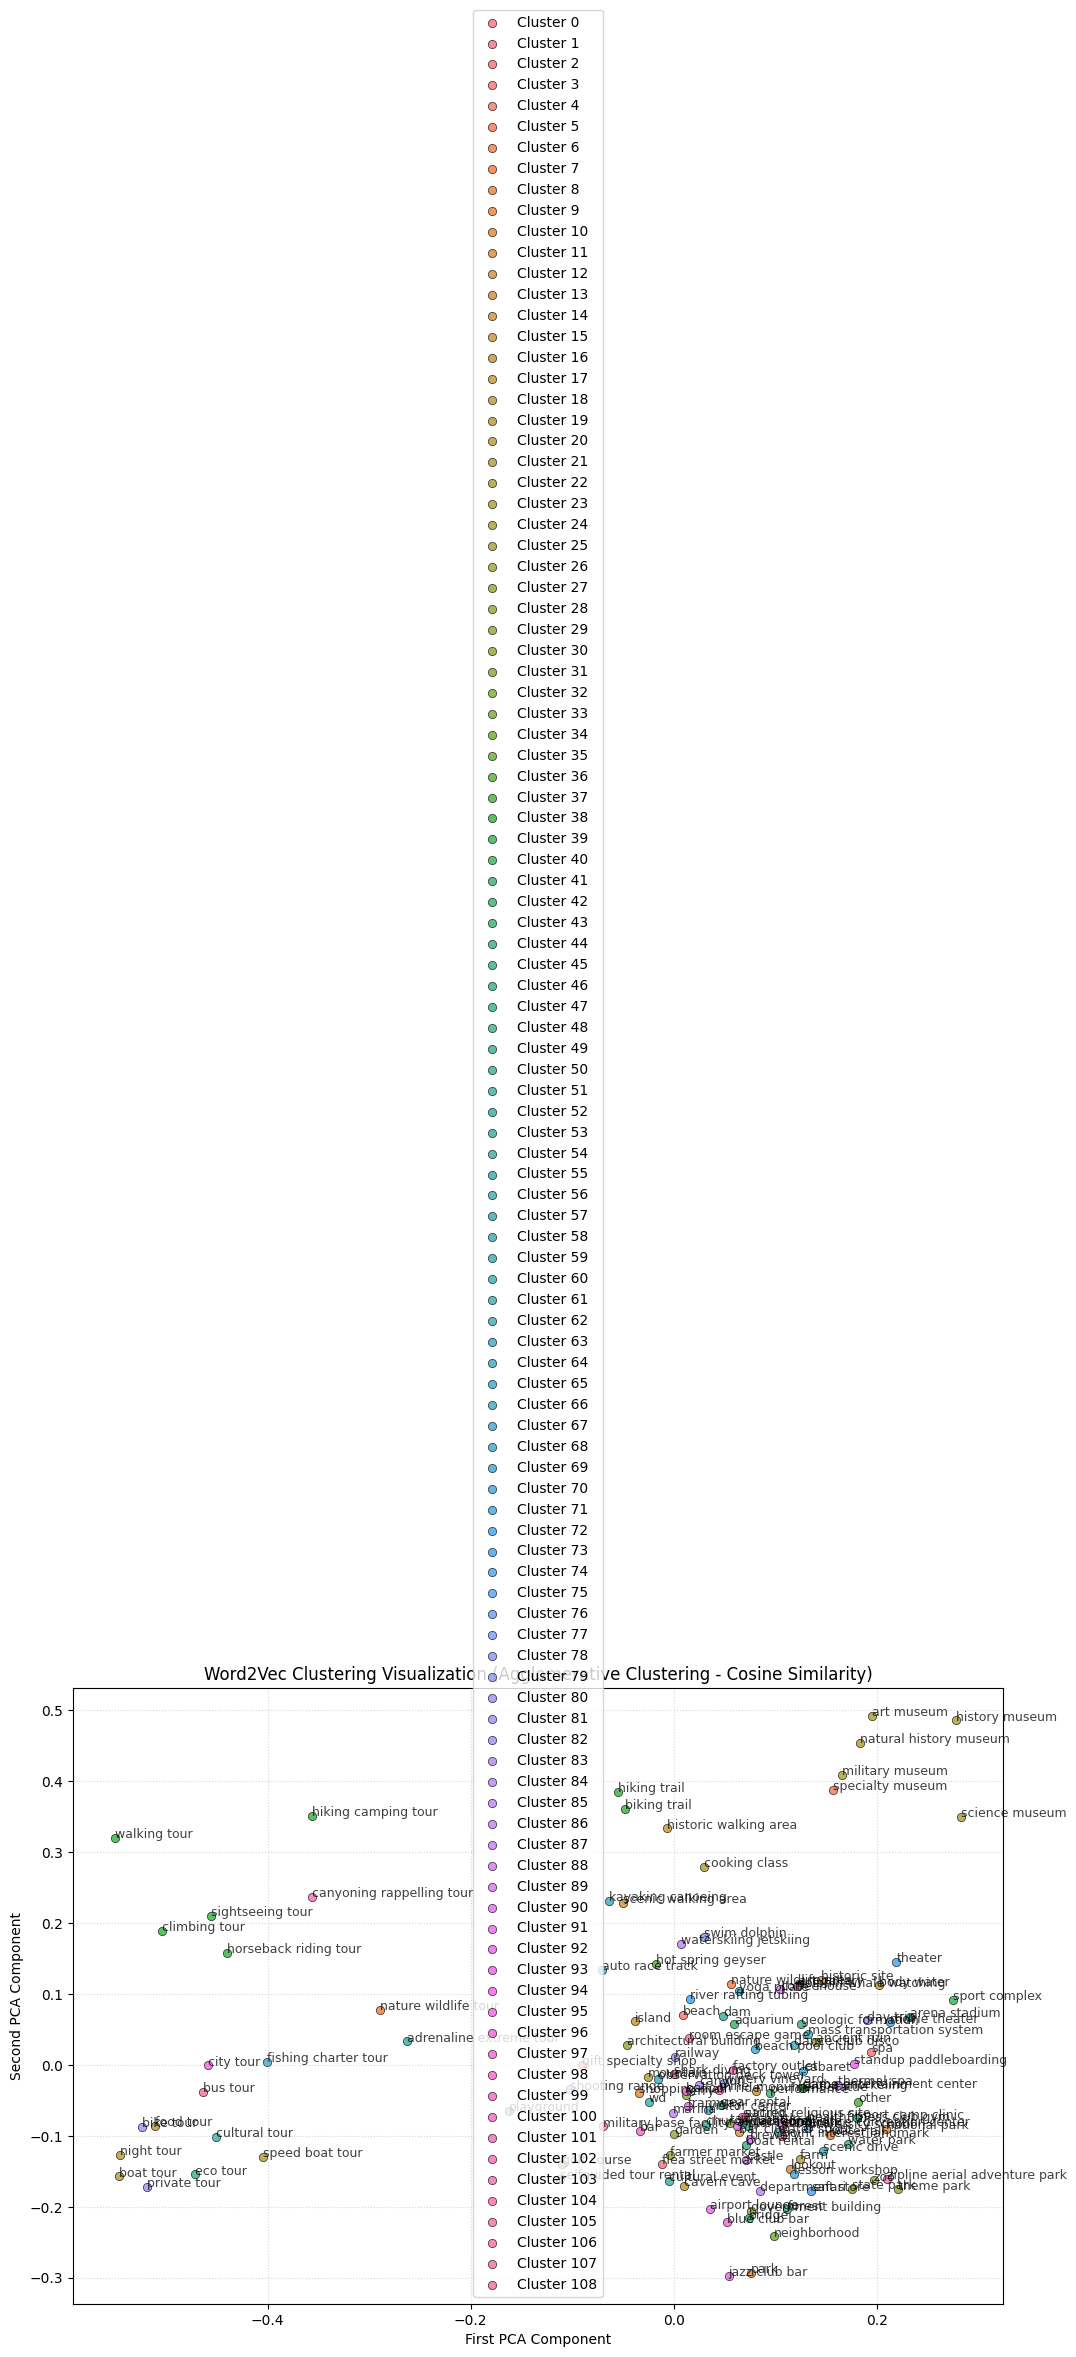

In [59]:
pca = PCA(n_components=2)
word_vectors_2d = pca.fit_transform(word_vectors)

# ✅ Define colors for clusters
num_clusters = len(set(word_clusters_dbscan))
palette = sns.color_palette("husl", num_clusters)

# ✅ Scatter plot with cluster colors
plt.figure(figsize=(12, 8))
for cluster_id in set(word_clusters_dbscan):
    idx = np.where(word_clusters_dbscan == cluster_id)
    plt.scatter(word_vectors_2d[idx, 0], word_vectors_2d[idx, 1], 
                label=f"Cluster {cluster_id}", color=palette[cluster_id], alpha=0.8, edgecolors='k', linewidth=0.5)

# ✅ Annotate words more clearly
for i, word in enumerate(words):
    plt.annotate(word, (word_vectors_2d[i, 0], word_vectors_2d[i, 1]), fontsize=9, alpha=0.75)

# ✅ Improve visualization settings
plt.title("Word2Vec Clustering Visualization (Agglomerative Clustering - Cosine Similarity)")
plt.xlabel("First PCA Component")
plt.ylabel("Second PCA Component")
plt.grid(True, linestyle='dotted', alpha=0.5)
plt.legend()
plt.show()

/Users/ittichaiboonyarakthunya/Documents/WorkDir/developments/IS_Project/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



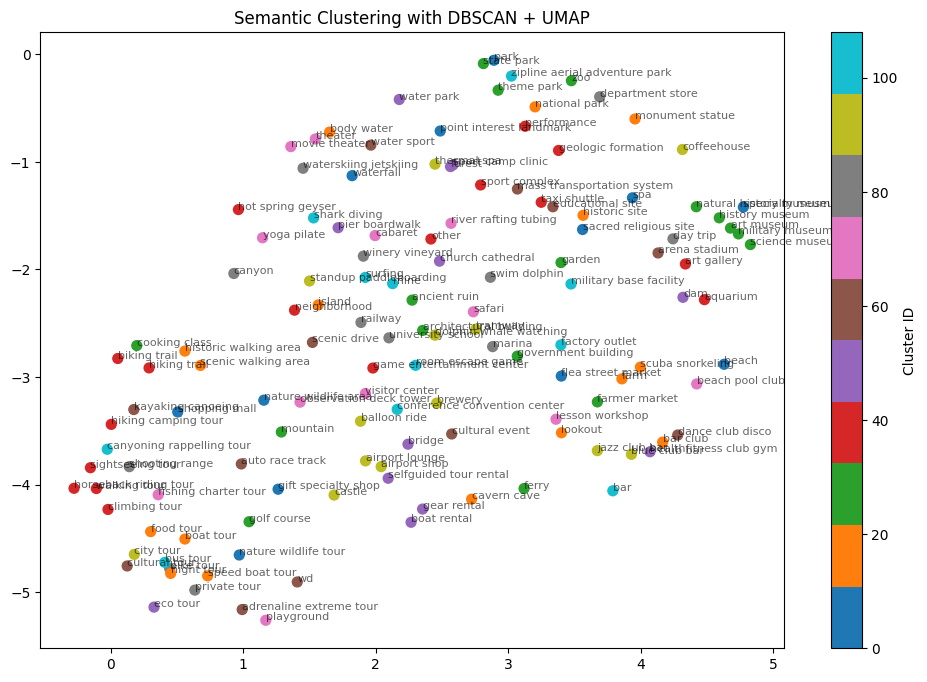

In [60]:
X = np.array(word_vectors)
labels = np.array(word_clusters_dbscan)

# Reduce dimensions to 2D
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, metric='cosine')
embedding = reducer.fit_transform(X)

# Plot with cluster colors
plt.figure(figsize=(12, 8))
scatter = plt.scatter(embedding[:, 0], embedding[:, 1], c=labels, cmap='tab10', s=50)

# Optional: Annotate with words
for i, word in enumerate(words):
    if labels[i] != -1:  # -1 = noise
        plt.annotate(word, (embedding[i, 0], embedding[i, 1]), fontsize=8, alpha=0.6)

plt.title("Semantic Clustering with DBSCAN + UMAP")
plt.colorbar(scatter, label='Cluster ID')
plt.show()

/Users/ittichaiboonyarakthunya/Documents/WorkDir/developments/IS_Project/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/var/folders/fk/449tdf_12hzd2r7ps4659q0m0000gn/T/ipykernel_2858/3607167339.py:16: UserWarning:

Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.

/var/folders/fk/449tdf_12hzd2r7ps4659q0m0000gn/T/ipykernel_2858/3607167339.py:16: UserWarning:

Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.

/Users/ittichaiboonyarakthunya/Documents/WorkDir/developments/IS_Project/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning:

Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.



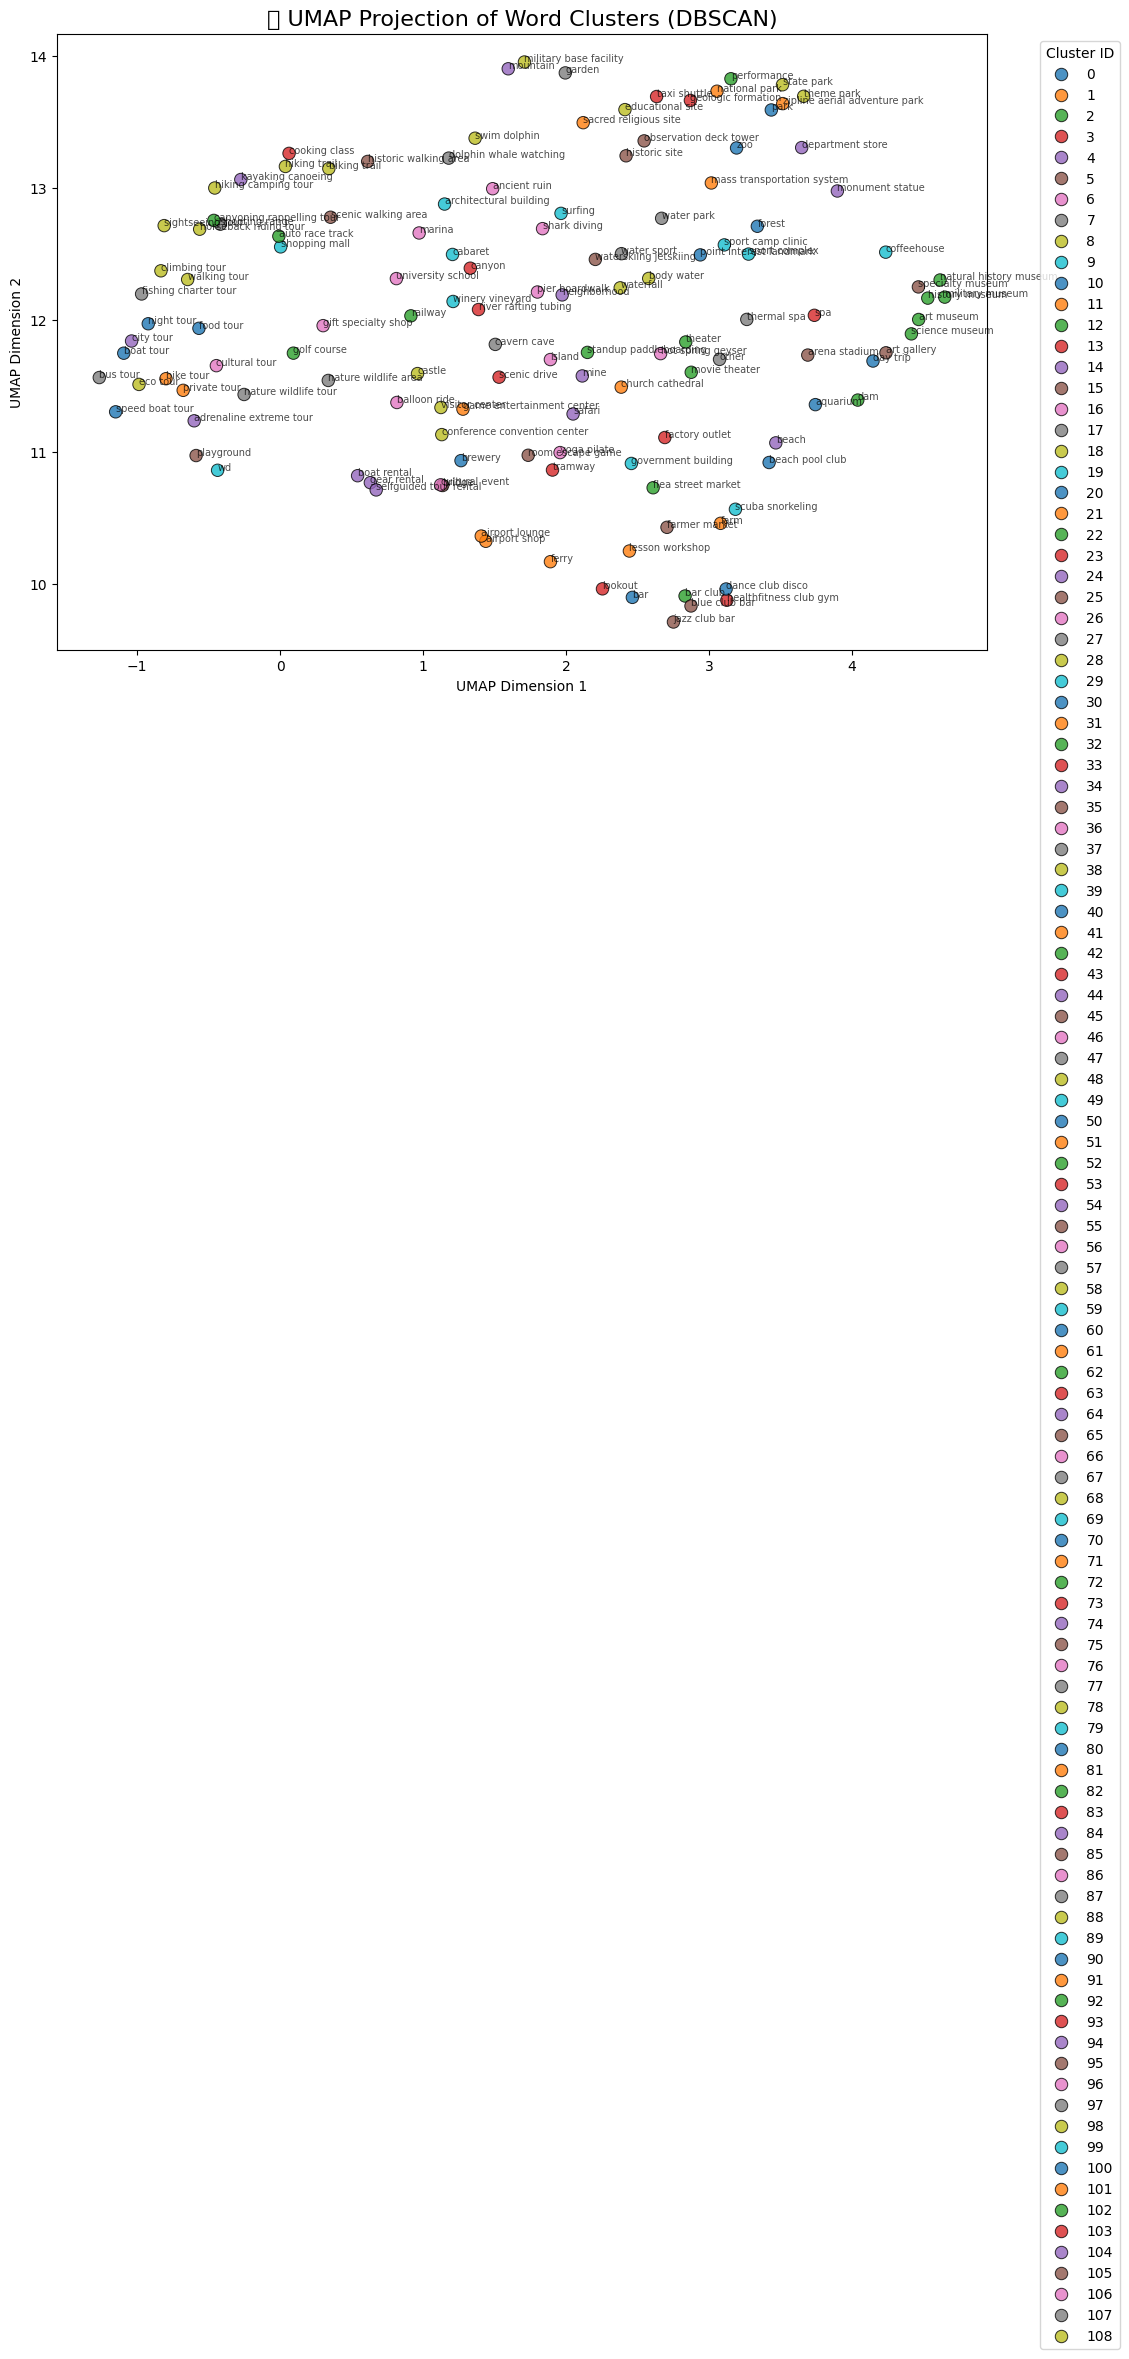

In [61]:
umap_embedding = umap.UMAP(n_neighbors=15, min_dist=0.1, metric="cosine").fit_transform(word_vectors)

# Step 2: Plot clusters
plt.figure(figsize=(12, 8))
sns.scatterplot(x=umap_embedding[:, 0], y=umap_embedding[:, 1], hue=word_clusters_dbscan, palette="tab10", s=80, alpha=0.8, edgecolor="k")

# Optional: Annotate words
for i, word in enumerate(words):
    if word_clusters_dbscan[i] != -1:  # skip noise if needed
        plt.text(umap_embedding[i, 0], umap_embedding[i, 1], word, fontsize=7, alpha=0.7)

plt.title("🔍 UMAP Projection of Word Clusters (DBSCAN)", fontsize=16)
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.legend(title="Cluster ID", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [62]:
from collections import defaultdict

cluster_words_dict = defaultdict(list)
for word, label in zip(words, word_clusters_dbscan):
    cluster_words_dict[label].append(word)

# Print top 10 from each cluster
for cid, wlist in cluster_words_dict.items():
    print(f"\n🔹 Cluster {cid} ({len(wlist)} words):\n" + ", ".join(wlist[:10]) + " ...")



🔹 Cluster 0 (1 words):
point interest landmark ...

🔹 Cluster 1 (1 words):
sacred religious site ...

🔹 Cluster 2 (1 words):
flea street market ...

🔹 Cluster 3 (1 words):
spa ...

🔹 Cluster 4 (1 words):
beach ...

🔹 Cluster 5 (1 words):
specialty museum ...

🔹 Cluster 6 (1 words):
gift specialty shop ...

🔹 Cluster 7 (2 words):
nature wildlife area, nature wildlife tour ...

🔹 Cluster 8 (1 words):
waterfall ...

🔹 Cluster 9 (1 words):
shopping mall ...

🔹 Cluster 10 (1 words):
park ...

🔹 Cluster 11 (1 words):
national park ...

🔹 Cluster 12 (1 words):
bar club ...

🔹 Cluster 13 (1 words):
lookout ...

🔹 Cluster 14 (1 words):
monument statue ...

🔹 Cluster 15 (3 words):
historic site, scenic walking area, historic walking area ...

🔹 Cluster 16 (1 words):
island ...

🔹 Cluster 17 (1 words):
cavern cave ...

🔹 Cluster 18 (1 words):
body water ...

🔹 Cluster 19 (1 words):
scuba snorkeling ...

🔹 Cluster 20 (4 words):
boat tour, food tour, speed boat tour, night tour ...

🔹 Cluster 21 (

In [30]:
# ✅ Map DBSCAN clustering results to `combined_details_df['cluster']`
word_to_cluster = {word: cluster_id for word, cluster_id in zip(words, word_clusters_dbscan)}

# Function to assign cluster labels to `combined_details_df`
def assign_cluster(tags):
    tag_list = tags.split(", ")  # Convert tag string to list
    cluster_ids = [word_to_cluster.get(tag, -1) for tag in tag_list]  # Get clusters, default to -1 if not found
    
    # Return the most common cluster in case multiple tags belong to different clusters
    return max(set(cluster_ids), key=cluster_ids.count) if cluster_ids else -1  

# ✅ Apply function to assign clusters
combined_details_df['cluster'] = combined_details_df['label'].apply(assign_cluster)

In [31]:
# ✅ Filter rows where 'label' contains the word 'museum'
filtered_df = combined_details_df[combined_details_df['label'].str.contains('museum', case=False, na=False)]

# ✅ Get unique labels
unique_museum_labels = filtered_df['label'].unique()

# ✅ Display results
print("Unique Museum Labels:", unique_museum_labels)

Unique Museum Labels: ['history museum' 'specialty museum' 'natural history museum' 'art museum'
 'science museum' 'military museum']


In [32]:
combined_details_df[['name', 'label', 'cluster']]

,name,label,cluster
0,House of Opium,history museum,22
1,Opium Bar,bar club,12
2,Wat Phra That Doi Saket,sacred religious site,1
3,Mae Ping River Cruise,boat tour,20
4,Pai River,body water,18
...,...,...,...
1761,Chao Lao Beach,beach,4
1762,Chao Lao Fish Bridge,bridge,45
1763,Wat Burapa Temple,sacred religious site,1
1764,Kung Wiman Beach,beach,4


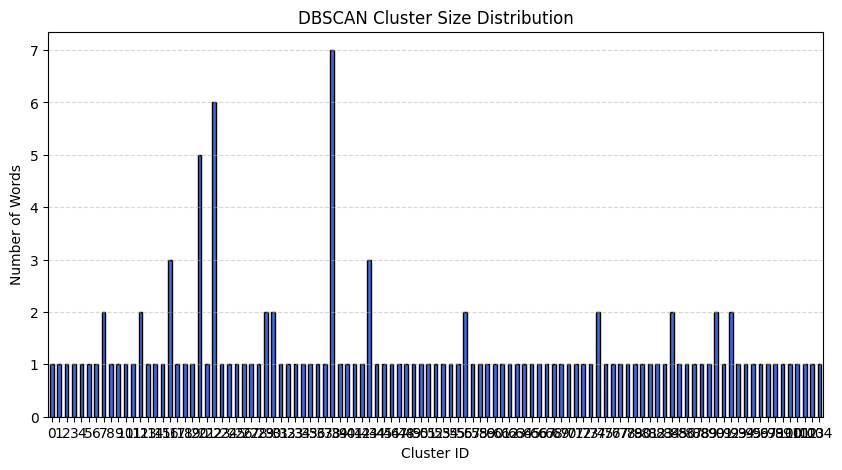

In [28]:

# ✅ Count cluster sizes
cluster_counts = pd.Series(word_clusters_dbscan).value_counts()

# ✅ Bar chart of cluster sizes
plt.figure(figsize=(10, 5))
cluster_counts.sort_index().plot(kind="bar", color="royalblue", edgecolor="black")
plt.xlabel("Cluster ID")
plt.ylabel("Number of Words")
plt.title("DBSCAN Cluster Size Distribution")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

In [66]:
# ✅ Count noise vs. clustered points
num_noise = list(word_clusters_dbscan).count(-1)
num_clustered = len(word_clusters_dbscan) - num_noise

# ✅ Labels and values
labels = ["Clustered Data", "Noise (Cluster -1)"]
values = [num_clustered, num_noise]
colors = ["royalblue", "crimson"]

# ✅ Plotly Pie Chart
fig = go.Figure(data=[go.Pie(
    labels=labels,
    values=values,
    hole=0.3,  # Donut style
    marker=dict(colors=colors, line=dict(color='#FFFFFF', width=2)),
    textinfo='label+percent',
    insidetextorientation='radial'
)])

fig.update_layout(
    title_text="📊 DBSCAN Noise Ratio",
    title_font_size=20,
    legend=dict(orientation="h", y=-0.1, x=0.3),
    margin=dict(t=60, b=0, l=0, r=0)
)

fig.show()


In [30]:
df_box = silhouette_df.copy()
df_box["Cluster"] = df_box["Cluster"].astype(str)

# ✅ Plot ด้วย Plotly Express
fig = px.box(
    df_box,
    y="Cluster",  # แนวนอน (Cluster เป็นแกน Y)
    x="Silhouette Score",
    color="Cluster",
    points="outliers",  # แสดง outliers ชัดเจน
    title="📦 Silhouette Score per Cluster (DBSCAN)",
    template="plotly_white",
)

fig.update_layout(
    yaxis_title="Cluster ID",
    xaxis_title="Silhouette Score",
    title_font_size=20,
    width=950,
    height=600,
    boxmode="group",
    margin=dict(t=80, b=60, l=80, r=40),
    showlegend=False
)

fig.update_traces(marker=dict(size=4, opacity=0.6), line=dict(width=1.5))

fig.show()

NameError: name 'silhouette_df' is not defined

In [33]:
cluster_vectors = []
cluster_ids = []

for cluster_id in sorted(set(word_clusters_dbscan)):
    if cluster_id != -1:  # Ignore noise
        vecs = [word_vectors[i] for i in range(len(word_clusters_dbscan)) if word_clusters_dbscan[i] == cluster_id]
        cluster_vectors.append(np.mean(vecs, axis=0))
        cluster_ids.append(f"Cluster {cluster_id}")

# ✅ Compute cosine similarity matrix
cluster_sim_matrix = cosine_similarity(cluster_vectors)

# ✅ Convert to DataFrame for Plotly
sim_df = pd.DataFrame(cluster_sim_matrix, index=cluster_ids, columns=cluster_ids)

# ✅ Plot heatmap
fig = px.imshow(
    sim_df,
    text_auto=".2f",
    color_continuous_scale="RdBu",
    aspect="auto",
    title="🔍 Cluster Similarity Heatmap (DBSCAN)",
)

fig.update_layout(
    xaxis_title="Clusters",
    yaxis_title="Clusters",
    title_font_size=20,
    width=800,
    height=700,
    margin=dict(l=50, r=50, t=80, b=50)
)

fig.show()

In [34]:
cluster_counts = pd.Series(word_clusters_dbscan).value_counts().sort_index()
cluster_counts = cluster_counts[cluster_counts.index != -1]  # remove noise

fig = px.bar(x=cluster_counts.index.astype(str), y=cluster_counts.values,
             labels={"x": "Cluster ID", "y": "Number of Tags"},
             title="Cluster Size Distribution")
fig.show()


In [35]:
similar_pairs = []
for i in range(len(cluster_sim_matrix)):
    for j in range(i+1, len(cluster_sim_matrix)):
        sim = cluster_sim_matrix[i][j]
        if sim > 0.3:
            similar_pairs.append((f"Cluster {i}", f"Cluster {j}", round(sim, 3)))

similar_df = pd.DataFrame(similar_pairs, columns=["Cluster A", "Cluster B", "Similarity"])
similar_df.sort_values("Similarity", ascending=False)


,Cluster A,Cluster B,Similarity
11,Cluster 20,Cluster 81,0.501
3,Cluster 5,Cluster 22,0.469
16,Cluster 38,Cluster 102,0.436
12,Cluster 20,Cluster 94,0.434
13,Cluster 20,Cluster 107,0.430
10,Cluster 20,Cluster 48,0.408
4,Cluster 8,Cluster 47,0.390
8,Cluster 11,Cluster 58,0.389
19,Cluster 48,Cluster 81,0.378
17,Cluster 39,Cluster 49,0.375


In [75]:
combined_details_df.to_parquet("output/cosine_clusters_V2.parquet", index=False)

In [6]:
combined_details_df = pd.read_parquet("output/cosine_clusters_V2.parquet")

In [40]:
merge_candidates = similar_df[similar_df["Similarity"] > 0.3]
for _, row in merge_candidates.iterrows():
    print(f"Consider merging {row['Cluster A']} and {row['Cluster B']} (Sim: {row['Similarity']})")


Consider merging Cluster 4 and Cluster 70 (Sim: 0.3569999933242798)
Consider merging Cluster 5 and Cluster 6 (Sim: 0.35499998927116394)
Consider merging Cluster 5 and Cluster 22 (Sim: 0.4690000116825104)
Consider merging Cluster 8 and Cluster 47 (Sim: 0.38999998569488525)
Consider merging Cluster 10 and Cluster 11 (Sim: 0.33500000834465027)
Consider merging Cluster 10 and Cluster 28 (Sim: 0.35899999737739563)
Consider merging Cluster 11 and Cluster 28 (Sim: 0.3019999861717224)
Consider merging Cluster 11 and Cluster 58 (Sim: 0.3889999985694885)
Consider merging Cluster 20 and Cluster 38 (Sim: 0.33500000834465027)
Consider merging Cluster 20 and Cluster 48 (Sim: 0.40799999237060547)
Consider merging Cluster 20 and Cluster 81 (Sim: 0.5009999871253967)
Consider merging Cluster 20 and Cluster 94 (Sim: 0.4339999854564667)
Consider merging Cluster 20 and Cluster 107 (Sim: 0.4300000071525574)
Consider merging Cluster 21 and Cluster 25 (Sim: 0.34299999475479126)
Consider merging Cluster 28 and

In [41]:
# Step 1: Build initial mapping from Cluster B → Cluster A
merge_map = {}
for _, row in similar_df[similar_df["Similarity"] > 0.3].iterrows():
    a = int(row["Cluster A"].split()[1])  # extract number from "Cluster XX"
    b = int(row["Cluster B"].split()[1])
    merge_map[b] = a  # merge B into A

# Step 2: Resolve recursively in case of chained merges
def resolve_cluster(c, mapping):
    visited = set()
    while c in mapping and c not in visited:
        visited.add(c)
        c = mapping[c]
    return c

# Step 3: Create new_cluster column
combined_details_df['new_cluster'] = combined_details_df['cluster'].apply(lambda c: resolve_cluster(c, merge_map))


In [43]:
filtered_new_clusters = combined_details_df[combined_details_df['new_cluster'] != combined_details_df['cluster']]

In [46]:
filtered_new_clusters[['location_id', 'name', 'label','cluster', 'new_cluster']]

,location_id,name,label,cluster,new_cluster
0,456633,House of Opium,history museum,22,5
8,3748600,Golden Triangle Tours - Day Tours,sightseeing tour,38,20
10,4322762,Doi Khun Tan National Park,national park,11,10
37,8768959,Nuan Thip Market,farmer market,25,21
38,10130101,Natural History Museum,natural history museum,22,5
...,...,...,...,...,...
1708,8776257,Thapong Fruit Market,farmer market,25,21
1744,11867768,The Royal Agricultural Station Angkhang,biking trail,38,20
1746,8766125,Weapon Museum,military museum,22,5
1748,9785391,Dinosaur Footprints Park at Tha Uthen,educational site,58,10


In [ ]:
# combined_details_df.to_parquet("output/cosine_clusters_V3.parquet", index=False)
combined_details_df = pd.read_parquet("output/cosine_clusters_V3.parquet")

In [58]:
# Step 1: Prepare mapping from new_cluster to non-empty list of labels
cluster_word_map = (
    combined_details_df
    .dropna(subset=["label"])
    .groupby("new_cluster")["label"]
    .apply(lambda x: list(x.astype(str)))
    .to_dict()
)

# Step 2: Setup canvas
cluster_ids = sorted(cluster_word_map.keys())
n_clusters = len(cluster_ids)

n_clusters

93

In [61]:
combined_details_df[combined_details_df['cluster'] == 37]

,location_id,name,description,web_url,latitude,longitude,website,write_review,rating,rating_image_url,...,trip_types_solo,trip_types_couples,trip_types_business,trip_types_family,trip_types_friends,label,keyword,frequncy_keyword,cluster,new_cluster
317,25279698,CHIANG MAI: One day Doi Inthanon Tour Waterfal...,CHIANG MAI: One day Doi Inthanon (No trekking)...,https://www.tripadvisor.com/Attraction_Review-...,0.000000,0.000000,https://www.viator.com/tours/Chiang-Mai/CHIANG...,https://www.tripadvisor.com/UserReview-g196165...,0.0,None,...,0,0,0,0,0,other,,,37,37
318,26663985,CHIANG MAI: Doi Inthanon NationPark-Waterfall ...,Swap the hustle and bustle of central Chiang M...,https://www.tripadvisor.com/Attraction_Review-...,0.000000,0.000000,https://www.viator.com/tours/Chiang-Mai/CHIANG...,https://www.tripadvisor.com/UserReview-g790337...,0.0,None,...,0,0,0,0,0,other,,,37,37
320,25179042,CHIANG MAI:Join Tour Doi Inthanon Nation Park-...,Doi Inthanon is one of the most popular nation...,https://www.tripadvisor.com/Attraction_Review-...,0.000000,0.000000,https://www.viator.com/tours/Chiang-Mai/CHIANG...,https://www.tripadvisor.com/UserReview-g293917...,0.0,None,...,0,0,0,0,0,other,,,37,37
770,24992332,Elephant Dream Project,"Bring elephants back to the forest Hi, my name...",https://www.tripadvisor.com/Attraction_Review-...,0.000000,0.000000,https://www.elephantdreamproject.com,https://www.tripadvisor.com/UserReview-g293917...,5.0,https://www.tripadvisor.com/img/cdsi/img2/rati...,...,36,71,0,13,70,other,,,37,37
1048,17065409,Muai's Thai Traditional Cooking Academy,Traditional Thai cooking academy on Koh Phanga...,https://www.tripadvisor.com/Attraction_Review-...,9.712846,99.994156,http://www.facebook.com/Muais-Thai-Traditional...,https://www.tripadvisor.com/UserReview-g152717...,5.0,https://www.tripadvisor.com/img/cdsi/img2/rati...,...,12,54,0,27,23,other,,,37,37
1309,24049771,The Selfie Experience Phuket - Museum,A super fun day out with friends and family ta...,https://www.tripadvisor.com/Attraction_Review-...,0.000000,0.000000,https://www.tse.asia,https://www.tripadvisor.com/UserReview-g121578...,5.0,https://www.tripadvisor.com/img/cdsi/img2/rati...,...,7,33,1,34,17,other,,,37,37
1322,9996704,Shopping Sale Karon Plaza,"Also known as the Karon Bazaar, this plaza is ...",https://www.tripadvisor.com/Attraction_Review-...,7.844881,98.294200,None,https://www.tripadvisor.com/UserReview-g121578...,3.0,https://www.tripadvisor.com/img/cdsi/img2/rati...,...,4,23,1,18,6,other,flea,flea street market,37,37
1577,26544358,Ning's Thai Cooking Class in Khao Lak,Passion for cooking Traditional recipes from ...,https://www.tripadvisor.com/Attraction_Review-...,0.000000,0.000000,None,https://www.tripadvisor.com/UserReview-g297914...,5.0,https://www.tripadvisor.com/img/cdsi/img2/rati...,...,15,154,0,95,28,other,,,37,37
1747,17659665,Itti Cnx Vantours,Itti Cnx Vantours is a private tours and trans...,https://www.tripadvisor.com/Attraction_Review-...,0.000000,0.000000,https://www.facebook.com/itticnxvantours,https://www.tripadvisor.com/UserReview-g293917...,5.0,https://www.tripadvisor.com/img/cdsi/img2/rati...,...,1,16,0,29,18,other,,,37,37


⚠️ WordCloud skipped for Cluster 37 (after stopwords removal, 0 usable words).


/var/folders/fk/449tdf_12hzd2r7ps4659q0m0000gn/T/ipykernel_2145/328573941.py:44: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.

/Users/ittichaiboonyarakthunya/Documents/WorkDir/developments/IS_Project/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning:

Glyph 129504 (\N{BRAIN}) missing from font(s) DejaVu Sans.



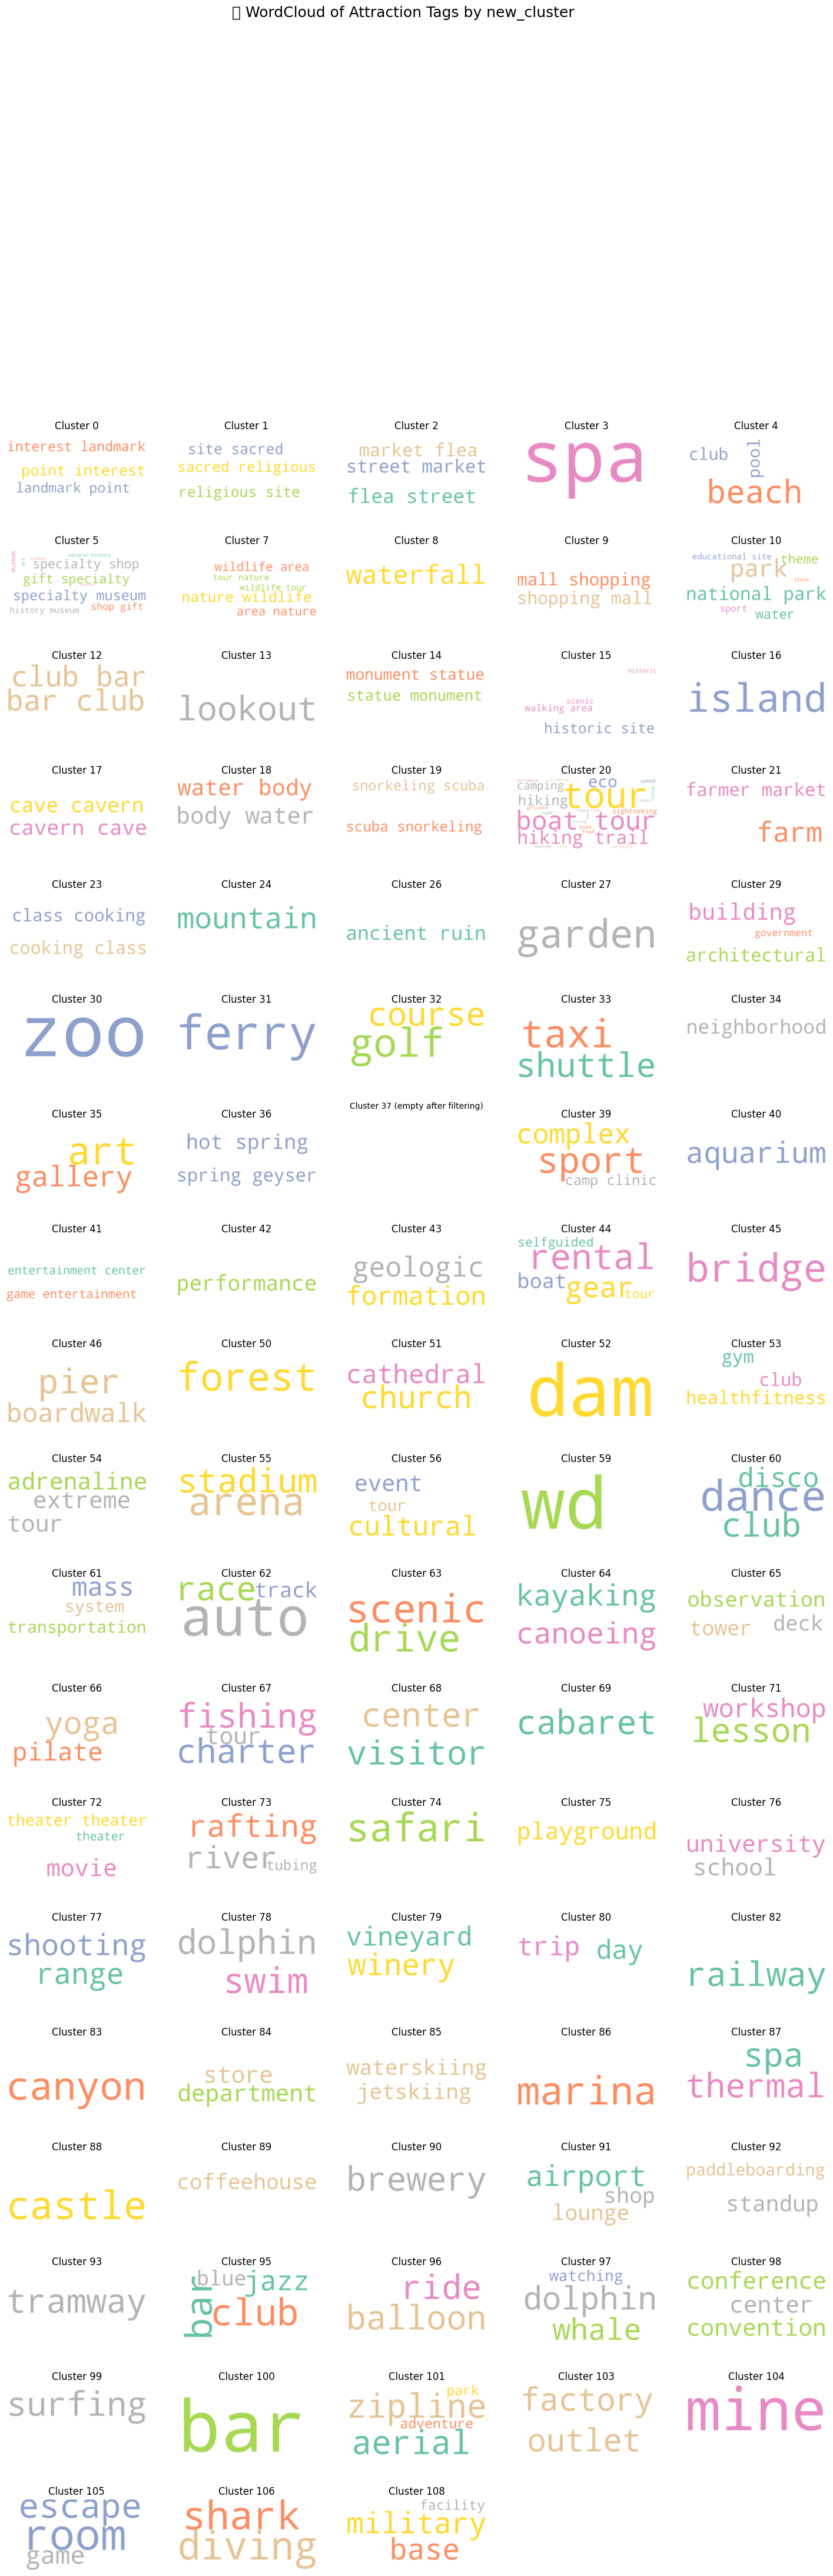

In [59]:
import matplotlib.gridspec as gridspec

cols = 5
rows = math.ceil(n_clusters / cols)

fig = plt.figure(figsize=(18, 2.5 * rows))
gs = gridspec.GridSpec(rows, cols, figure=fig, hspace=0.3, wspace=0.2)

for idx, cluster_id in enumerate(cluster_ids):
    r, c = divmod(idx, cols)
    ax = fig.add_subplot(gs[r, c])

    words = cluster_word_map[cluster_id]
    text_blob = " ".join(words).strip()

    if not text_blob:
        print(f"⚠️ Skipping empty cluster: {cluster_id}")
        ax.axis("off")
        ax.set_title(f"Cluster {cluster_id} (empty)", fontsize=10)
        continue

    # Step 3: Generate WordCloud
    wordcloud = WordCloud(
        background_color="white",
        colormap="Set2",
        max_words=100,
        width=800,
        height=400
    )

    try:
        wc = wordcloud.generate(text_blob)
    except ValueError:
        print(f"⚠️ WordCloud skipped for Cluster {cluster_id} (after stopwords removal, 0 usable words).")
        ax.axis("off")
        ax.set_title(f"Cluster {cluster_id} (empty after filtering)", fontsize=10)
        continue

    ax.imshow(wc, interpolation='bilinear')
    ax.axis("off")
    ax.set_title(f"Cluster {cluster_id}", fontsize=12)

fig.suptitle("🧠 WordCloud of Attraction Tags by new_cluster", fontsize=18, y=1.03)
plt.tight_layout()
plt.show()

In [71]:
attractions_map_ids = pd.read_csv('../../dataset/locations/TripAdvisor_Location_Ids.csv', encoding='utf-8', index_col=False)
attractions_map_ids.drop(columns=['Unnamed: 0'], inplace=True)
attractions_map_ids

,location_id,name,province,place_id
0,2209612,Wat Ratchabophit,Bangkok,P03013220
1,2273363,Wat Rajapradit Sathitmahasimaram Rajaworavihara,Bangkok,P03013220
2,311043,Wat Phra Chetuphon,Bangkok,P03013220
3,317504,Temple Of Dawn (Wat Arun),Bangkok,P03013220
4,456322,Wat Umong,Bangkok,P03013220
...,...,...,...,...
1899,13009981,Thai Sabai Massage,Samut Songkhram,P03012297
1900,3256228,Phuket Dragon Muay Thai,Samut Songkhram,P03012297
1901,2515972,Thai Cooking School Phuket,Samut Songkhram,P03012297
1902,13365103,Nong Bua Thai Dessert Market,Samut Songkhram,P03000251


In [72]:
attractions_map_ids.to_parquet("../../frontend/inputs/attractions_map_ids.parquet", index=False, compression="gzip", engine="pyarrow")